# 05 — EfficientNet-B0 + Landmarks (Proposed Improvement)
**BTL IS54A — Người 5**

Model **CẢI TIẾN** kết hợp 2 nguồn đặc trưng:
- **Deep features** từ EfficientNet-B0 (1280-dim) — đặc trưng thị giác từ pixel
- **Geometric features** từ MediaPipe Face Mesh (956-dim) — vị trí 478 điểm khuôn mặt

Hai nhánh được **concatenate** rồi đưa qua classification head.

Pipeline 2 giai đoạn giống các model khác:
- Phase 1: AffectNet (8 cảm xúc)
- Phase 2: Student Engagement (6 trạng thái)

**Yêu cầu:** GPU T4, runtime ~80–100 phút (cộng thời gian pre-extract landmarks).

## Cell 1 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install mtcnn mediapipe -q

import sys
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/data')
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/models')

import tensorflow as tf
print(f'TF version : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.7 MB/s eta 0:00:00
TF version : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Đường dẫn + Import

In [2]:
AFFECTNET_DIR = '/content/drive/MyDrive/ProjectBTL/AffectNet'
STUDENT_RAW   = '/content/drive/MyDrive/ProjectBTL/Student Dataset/Student-engagement-dataset'
DATA_DIR      = '/content/drive/MyDrive/ProjectBTL/BTL/data'
WEIGHTS_DIR   = '/content/drive/MyDrive/ProjectBTL/BTL/weights'
RESULTS_DIR   = '/content/drive/MyDrive/ProjectBTL/BTL/results'

from preprocess import init_mtcnn, _try_mtcnn_crop
init_mtcnn()

from efficientnet_landmarks import (
    build_model, freeze_backbone, unfreeze_backbone,
    load_phase1_weights_for_phase2, LANDMARK_DIM
)

import numpy as np
import pandas as pd
import cv2
import os
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# ── Dùng Tasks API mới — ổn định, không bị bug protobuf ─────────
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
MODEL_PATH = "/content/face_landmarker.task"

if not os.path.exists(MODEL_PATH):
    print('Đang tải MediaPipe model...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print('Tải xong.')

base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,
)
face_detector = vision.FaceLandmarker.create_from_options(options)

print(f'LANDMARK_DIM = {LANDMARK_DIM}')
print('Imports OK — dùng MediaPipe Tasks API')

[preprocess] MTCNN khởi tạo thành công.
Đang tải MediaPipe model...
Tải xong.
LANDMARK_DIM = 956
Imports OK — dùng MediaPipe Tasks API


## Cell 3 — Copy AffectNet sang local SSD

Bắt buộc để training nhanh (~150ms/step thay vì 8s/step).

In [3]:
import shutil
if not os.path.exists('/content/affectnet_local'):
    print('Copying AffectNet → /content/affectnet_local/ ...')
    shutil.copytree(AFFECTNET_DIR, '/content/affectnet_local')
    print('Copy xong!')
else:
    print('Đã tồn tại.')
AFFECTNET_DIR = '/content/affectnet_local'
!du -sh /content/affectnet_local

Copying AffectNet → /content/affectnet_local/ ...
Copy xong!
388M	/content/affectnet_local


## Cell 4 — Hàm extract landmark

MediaPipe Face Mesh trả 478 điểm, mỗi điểm (x, y, z). Ta lấy (x, y) → vector 956-dim chuẩn hóa về [0, 1] theo kích thước ảnh.

In [4]:
def extract_landmarks_from_image(img_rgb):
    """
    Args: img_rgb — uint8 numpy array shape (H, W, 3) RGB.
    Returns: vector shape (956,) float32. Toàn 0 nếu không detect được.
    """
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results = face_detector.detect(mp_image)
    if not results.face_landmarks:
        return np.zeros(LANDMARK_DIM, dtype=np.float32)
    lm = results.face_landmarks[0]
    # MediaPipe Tasks API trả về 478 điểm. Lấy x, y.
    vec = np.array([[p.x, p.y] for p in lm[:478]], dtype=np.float32).flatten()
    # Đảm bảo đúng kích thước
    if vec.shape[0] < LANDMARK_DIM:
        vec = np.pad(vec, (0, LANDMARK_DIM - vec.shape[0]))
    elif vec.shape[0] > LANDMARK_DIM:
        vec = vec[:LANDMARK_DIM]
    return vec.astype(np.float32)

# Test với 1 ảnh
import glob
sample = glob.glob(f'/content/drive/MyDrive/ProjectBTL/AffectNet/Train/happy/*.png')[0]
img = cv2.cvtColor(cv2.imread(sample), cv2.COLOR_BGR2RGB)
lm = extract_landmarks_from_image(img)
print(f'Sample landmark shape: {lm.shape}')
print(f'Range: [{lm.min():.3f}, {lm.max():.3f}]')
print(f'Non-zero ratio: {(lm != 0).mean():.2%}')

Sample landmark shape: (956,)
Range: [0.216, 0.916]
Non-zero ratio: 100.00%


## Cell 5 — Pre-extract landmarks cho AffectNet (~15-20 phút)

Chạy 1 lần duy nhất. Lưu cache vào `/content/`.

In [5]:
import random

# Mapping label
LABEL_MAP_AF = {'anger':0,'contempt':1,'disgust':2,'fear':3,
                'happy':4,'neutral':5,'sad':6,'surprise':7}

def scan_affectnet(split_dir, subset_per_class=None):
    filepaths, labels = [], []
    for cls_dir in sorted(os.listdir(split_dir)):
        full = os.path.join(split_dir, cls_dir)
        if not os.path.isdir(full): continue
        cls = cls_dir.lower()
        if cls not in LABEL_MAP_AF: continue
        imgs = [os.path.join(full, f) for f in os.listdir(full)
                if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if subset_per_class and len(imgs) > subset_per_class:
            random.seed(42)
            imgs = random.sample(imgs, subset_per_class)
        filepaths.extend(imgs)
        labels.extend([LABEL_MAP_AF[cls]] * len(imgs))
    return filepaths, labels

def precompute_landmarks(filepaths, save_path, target_size=224):
    landmarks = np.zeros((len(filepaths), LANDMARK_DIM), dtype=np.float32)
    for i, fp in enumerate(filepaths):
        img = cv2.imread(fp)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (target_size, target_size))
        landmarks[i] = extract_landmarks_from_image(img_rgb)
        if i % 1000 == 0:
            print(f'  {i}/{len(filepaths)}')
    np.save(save_path, landmarks)
    print(f'  ✅ Lưu {save_path} — shape {landmarks.shape}')
    return landmarks

# Train
af_train_dir = f'{AFFECTNET_DIR}/Train'
train_paths, train_labels = scan_affectnet(af_train_dir, subset_per_class=1500)
print(f'Train: {len(train_paths)} ảnh')
if not os.path.exists('/content/af_train_landmarks.npy'):
    af_train_lm = precompute_landmarks(train_paths, '/content/af_train_landmarks.npy')
else:
    af_train_lm = np.load('/content/af_train_landmarks.npy')
    print('Đã có cache train landmarks.')

# Test
af_test_dir = f'{AFFECTNET_DIR}/Test'
test_paths, test_labels = scan_affectnet(af_test_dir, subset_per_class=None)
print(f'Test: {len(test_paths)} ảnh')
if not os.path.exists('/content/af_test_landmarks.npy'):
    af_test_lm = precompute_landmarks(test_paths, '/content/af_test_landmarks.npy')
else:
    af_test_lm = np.load('/content/af_test_landmarks.npy')
    print('Đã có cache test landmarks.')

# Lưu filepaths + labels để load lại
np.save('/content/af_train_paths.npy', np.array(train_paths))
np.save('/content/af_train_labels.npy', np.array(train_labels))
np.save('/content/af_test_paths.npy', np.array(test_paths))
np.save('/content/af_test_labels.npy', np.array(test_labels))
print('✅ Xong pre-extract AffectNet')

Train: 11729 ảnh
  0/11729
  1000/11729
  2000/11729
  3000/11729
  4000/11729
  5000/11729
  6000/11729
  7000/11729
  8000/11729
  9000/11729
  10000/11729
  11000/11729
  ✅ Lưu /content/af_train_landmarks.npy — shape (11729, 956)
Test: 14518 ảnh
  0/14518
  1000/14518
  2000/14518
  3000/14518
  4000/14518
  5000/14518
  6000/14518
  7000/14518
  8000/14518
  9000/14518
  10000/14518
  11000/14518
  12000/14518
  13000/14518
  14000/14518
  ✅ Lưu /content/af_test_landmarks.npy — shape (14518, 956)
✅ Xong pre-extract AffectNet


## Cell 6 — Build dataset Phase 1 (AffectNet)

In [6]:
from sklearn.utils.class_weight import compute_class_weight
from augmentation import augment_train, augment_val
from preprocess import normalize_imagenet

def build_affectnet_lm_dataset(filepaths, labels, landmarks, batch_size, is_train):
    """Dataset trả ((image, landmarks), label_onehot)."""
    fp_arr = np.array(filepaths)
    lb_arr = np.array(labels, dtype=np.int32)
    indices = np.arange(len(fp_arr))

    def gen():
        idx_order = indices.copy()
        if is_train:
            np.random.shuffle(idx_order)
        for idx in idx_order:
            fp = fp_arr[idx]
            lb = lb_arr[idx]
            lm = landmarks[idx]
            raw = tf.io.read_file(fp)
            img = tf.image.decode_png(raw, channels=3)
            img = tf.image.resize(img, [224, 224], method=tf.image.ResizeMethod.BICUBIC)
            img = tf.cast(img, tf.float32) / 255.0
            img = tf.clip_by_value(img, 0.0, 1.0)
            img.set_shape([224, 224, 3])
            if is_train:
                img = augment_train(img)
            img = normalize_imagenet(img)
            label_oh = tf.one_hot(lb, 8)
            yield (img, lm.astype(np.float32)), label_oh

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            (tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
             tf.TensorSpec(shape=(LANDMARK_DIM,), dtype=tf.float32)),
            tf.TensorSpec(shape=(8,), dtype=tf.float32),
        )
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Build train + test
train_ds = build_affectnet_lm_dataset(
    train_paths, train_labels, af_train_lm, batch_size=32, is_train=True
)
test_ds = build_affectnet_lm_dataset(
    test_paths, test_labels, af_test_lm, batch_size=32, is_train=False
)

# Class weights
cw = compute_class_weight('balanced', classes=np.arange(8), y=np.array(train_labels))
class_weights = {i: float(w) for i, w in enumerate(cw)}
print(f'class_weights: {class_weights}')

class_weights: {0: 0.9774166666666667, 1: 0.9774166666666667, 2: 1.1929414157851912, 3: 0.9774166666666667, 4: 0.9774166666666667, 5: 0.9774166666666667, 6: 0.9774166666666667, 7: 0.9774166666666667}


## Cell 7 — Build model + Freeze backbone

In [7]:
model_p1 = build_model(num_classes=8)
freeze_backbone(model_p1)
model_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)
model_p1.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[efficientnet_lm] Backbone FROZEN — trainable params: 477,128


Model: "EfficientNetB0_Landmarks_FER_8cls"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ landmark_input      │ (None, 956)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ denorm_to_0_255     │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_dense_1 (Dense)  │ (None, 128)       │    122,496 │ landmark_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ denorm_to_0_255[… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_dropout          │ (None, 128)       │          0 │ lm_dense_1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_dense_2 (Dense)  │ (None, 64)        │      8,256 │ lm_dropout[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 1344)      │          0 │ gap[0][0],        │
│ (Concatenate)       │                   │            │ lm_dense_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1344)      │          0 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256 (Dense)   │ (None, 256)       │    344,320 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_256[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 8)         │      2,056 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,526,699 (17.27 MB)

 Trainable params: 477,128 (1.82 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Cell 8 — Train Phase 1 Freeze (5 epoch)

In [8]:
history_p1_freeze = model_p1.fit(
    train_ds, validation_data=test_ds, epochs=5,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)
print(f"\nFreeze final val_acc: {history_p1_freeze.history['val_accuracy'][-1]:.4f}")

Epoch 1/5
    367/Unknown 163s 351ms/step - accuracy: 0.2869 - loss: 1.8363

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


367/367 ━━━━━━━━━━━━━━━━━━━━ 260s 616ms/step - accuracy: 0.3317 - loss: 1.7216 - val_accuracy: 0.4230 - val_loss: 1.5381 - learning_rate: 0.0010
Epoch 2/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 190s 518ms/step - accuracy: 0.3991 - loss: 1.5476 - val_accuracy: 0.4439 - val_loss: 1.4707 - learning_rate: 0.0010
Epoch 3/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 189s 516ms/step - accuracy: 0.4236 - loss: 1.4886 - val_accuracy: 0.4514 - val_loss: 1.4683 - learning_rate: 0.0010
Epoch 4/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 201s 549ms/step - accuracy: 0.4457 - loss: 1.4464 - val_accuracy: 0.4643 - val_loss: 1.4594 - learning_rate: 0.0010
Epoch 5/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 190s 519ms/step - accuracy: 0.4565 - loss: 1.4207 - val_accuracy: 0.4715 - val_loss: 1.4682 - learning_rate: 0.0010

Freeze final val_acc: 0.4715


## Cell 9 — Unfreeze + Train Phase 1 (10 epoch)

In [9]:
unfreeze_backbone(model_p1)
model_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy', metrics=['accuracy']
)

LOCAL_CKPT_P1 = '/content/weights_local/efficientnet_lm_phase1.weights.h5'
os.makedirs(os.path.dirname(LOCAL_CKPT_P1), exist_ok=True)

history_p1_unfreeze = model_p1.fit(
    train_ds, validation_data=test_ds, epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=LOCAL_CKPT_P1, monitor='val_accuracy',
            save_best_only=True, save_weights_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)

import shutil
shutil.copy(LOCAL_CKPT_P1, f'{WEIGHTS_DIR}/efficientnet_lm_phase1.weights.h5')
from google.colab import drive
drive.flush_and_unmount(); drive.mount('/content/drive')
print(f"\n✅ Phase 1 xong. Best val_acc: "
      f"{max(history_p1_unfreeze.history['val_accuracy']):.4f}")

[efficientnet_lm] Backbone UNFROZEN — trainable params: 4,484,676
Epoch 1/10
    367/Unknown 267s 506ms/step - accuracy: 0.2725 - loss: 2.1089
Epoch 1: val_accuracy improved from None to 0.40529, saving model to /content/weights_local/efficientnet_lm_phase1.weights.h5

Epoch 1: finished saving model to /content/weights_local/efficientnet_lm_phase1.weights.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 358s 755ms/step - accuracy: 0.2953 - loss: 1.9400 - val_accuracy: 0.4053 - val_loss: 1.5793 - learning_rate: 1.0000e-05
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.3466 - loss: 1.6735
Epoch 2: val_accuracy improved from 0.40529 to 0.44097, saving model to /content/weights_local/efficientnet_lm_phase1.weights.h5

Epoch 2: finished saving model to /content/weights_local/efficientnet_lm_phase1.weights.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 226s 617ms/step - accuracy: 0.3630 - loss: 1.6242 - val_accuracy: 0.4410 - val_loss: 1.5380 - learning_rate: 1.0000e-05
Epoch 3/10
367/367 ━━━━━━━━━━━━━

---
# 🎯 PHASE 2 — Fine-tune trên Student Engagement

## Cell 10 — Pre-extract landmarks cho Student (~5 phút)

Dataset Student đã được crop trước đó bởi MTCNN. Ta detect landmark trên ảnh đã crop.

In [10]:
# Pre-extract MTCNN crops Student giống các notebook khác
DST_BASE = '/content/student_cropped'
os.makedirs(DST_BASE, exist_ok=True)

def crop_and_save(src_path, dst_path):
    img = cv2.imread(src_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cropped = _try_mtcnn_crop(img_rgb, margin=0.10)
    if cropped is None: cropped = img_rgb
    cropped = cv2.resize(cropped, (224, 224))
    cv2.imwrite(dst_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))

from pathlib import Path
STUDENT_LABEL_MAP = {'Focused':0,'Confused':1,'Frustrated':2,
                     'Bored':3,'Drowsy':4,'Looking Away':5}

student_data = {}  # split → (paths, labels, landmarks)

for split in ['train', 'val', 'test']:
    csv_in = f'{DATA_DIR}/student_{split}.csv'
    df = pd.read_csv(csv_in)

    paths, labels, lms = [], [], []
    for i, row in df.iterrows():
        src = row['filepath']
        rel = Path(src).relative_to(STUDENT_RAW)
        dst = Path(DST_BASE) / rel
        dst.parent.mkdir(parents=True, exist_ok=True)
        if not dst.exists():
            crop_and_save(src, str(dst))
        paths.append(str(dst))
        labels.append(STUDENT_LABEL_MAP[row['label']])
        if i % 200 == 0: print(f'  [{split}] crop {i}/{len(df)}')

    # Extract landmarks từ cropped images
    lm_arr = np.zeros((len(paths), LANDMARK_DIM), dtype=np.float32)
    for i, p in enumerate(paths):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        lm_arr[i] = extract_landmarks_from_image(img)
        if i % 200 == 0: print(f'  [{split}] landmark {i}/{len(paths)}')

    student_data[split] = (paths, labels, lm_arr)
    print(f'✅ [{split}] {len(paths)} ảnh — landmarks shape {lm_arr.shape}')

print('✅ Xong pre-extract Student')

  [train] crop 0/1484
  [train] crop 200/1484
[preprocess] MTCNN error: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)
  [train] crop 400/1484
  [train] crop 600/1484
  [train] crop 800/1484
  [train] crop 1000/1484
  [train] crop 1200/1484
  [train] crop 1400/1484
  [train] landmark 0/1484
  [train] landmark 200/1484
  [train] landmark 400/1484
  [train] landmark 600/1484
  [train] landmark 800/1484
  [train] landmark 1000/1484
  [train] landmark 1200/1484
  [train] landmark 1400/1484
✅ [train] 1484 ảnh — landmarks shape (1484, 956)
  [val] crop 0/318
  [val] crop 200/318
  [val] landmark 0/318
  [val] landmark 200/318
✅ [val] 318 ảnh — 

## Cell 11 — Build dataset Student

In [11]:
def build_student_lm_dataset(paths, labels, landmarks, batch_size, is_train):
    fp_arr = np.array(paths)
    lb_arr = np.array(labels, dtype=np.int32)
    indices = np.arange(len(fp_arr))

    def gen():
        idx_order = indices.copy()
        if is_train: np.random.shuffle(idx_order)
        for idx in idx_order:
            fp = fp_arr[idx]
            lb = lb_arr[idx]
            lm = landmarks[idx]
            raw = tf.io.read_file(fp)
            img = tf.image.decode_jpeg(raw, channels=3)
            img = tf.cast(img, tf.float32) / 255.0
            img = tf.clip_by_value(img, 0.0, 1.0)
            img.set_shape([224, 224, 3])
            if is_train:
                img = augment_train(img)
            img = normalize_imagenet(img)
            label_oh = tf.one_hot(lb, 6)
            yield (img, lm.astype(np.float32)), label_oh

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            (tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
             tf.TensorSpec(shape=(LANDMARK_DIM,), dtype=tf.float32)),
            tf.TensorSpec(shape=(6,), dtype=tf.float32),
        )
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_student = build_student_lm_dataset(
    *student_data['train'], batch_size=16, is_train=True
)
val_student = build_student_lm_dataset(
    *student_data['val'], batch_size=16, is_train=False
)
test_student = build_student_lm_dataset(
    *student_data['test'], batch_size=16, is_train=False
)
print('✅ Datasets Student sẵn sàng')

✅ Datasets Student sẵn sàng


## Cell 12 — Build model Phase 2 + Load weights

In [12]:
model_p2 = build_model(num_classes=6)
load_phase1_weights_for_phase2(
    model_p2, '/content/weights_local/efficientnet_lm_phase1.weights.h5'
)
freeze_backbone(model_p2)
model_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)
model_p2.summary()

[efficientnet_lm] Loaded Phase 1 weights từ /content/weights_local/efficientnet_lm_phase1.weights.h5
[efficientnet_lm]   Copied weights: efficientnetb0
[efficientnet_lm]   Copied weights: lm_dense_1
[efficientnet_lm]   Copied weights: lm_dense_2
[efficientnet_lm]   Copied weights: dense_256
[efficientnet_lm] Layer 'predictions' (6 class) giữ random init.
[efficientnet_lm] Backbone FROZEN — trainable params: 476,614


Model: "EfficientNetB0_Landmarks_FER_6cls"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ landmark_input      │ (None, 956)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ denorm_to_0_255     │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_dense_1 (Dense)  │ (None, 128)       │    122,496 │ landmark_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ denorm_to_0_255[… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_dropout          │ (None, 128)       │          0 │ lm_dense_1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_dense_2 (Dense)  │ (None, 64)        │      8,256 │ lm_dropout[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 1344)      │          0 │ gap[0][0],        │
│ (Concatenate)       │                   │            │ lm_dense_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1344)      │          0 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256 (Dense)   │ (None, 256)       │    344,320 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_256[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 6)         │      1,542 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,526,185 (17.27 MB)

 Trainable params: 476,614 (1.82 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Cell 13 — Train Phase 2 (5 freeze + 10 unfreeze)

In [13]:
# Stage 1: Freeze
history_p2_freeze = model_p2.fit(
    train_student, validation_data=val_student, epochs=5,
    callbacks=[tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', patience=2, factor=0.5, verbose=1)],
    verbose=1
)

# Stage 2: Unfreeze
unfreeze_backbone(model_p2)
model_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy', metrics=['accuracy']
)

LOCAL_CKPT_P2 = '/content/weights_local/efficientnet_lm_phase2.weights.h5'

history_p2_unfreeze = model_p2.fit(
    train_student, validation_data=val_student, epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=LOCAL_CKPT_P2, monitor='val_accuracy',
            save_best_only=True, save_weights_only=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1),
    ],
    verbose=1
)

import shutil
shutil.copy(LOCAL_CKPT_P2, f'{WEIGHTS_DIR}/efficientnet_lm_phase2.weights.h5')
from google.colab import drive
drive.flush_and_unmount(); drive.mount('/content/drive')
print(f"\n✅ Phase 2 xong. Best val_acc: "
      f"{max(history_p2_unfreeze.history['val_accuracy']):.4f}")

Epoch 1/5
     93/Unknown 62s 352ms/step - accuracy: 0.6438 - loss: 0.9237

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


93/93 ━━━━━━━━━━━━━━━━━━━━ 81s 556ms/step - accuracy: 0.7850 - loss: 0.5868 - val_accuracy: 0.9403 - val_loss: 0.1923 - learning_rate: 0.0010
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.9191 - loss: 0.2259 - val_accuracy: 0.9591 - val_loss: 0.1239 - learning_rate: 0.0010
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.9252 - loss: 0.1886 - val_accuracy: 0.9654 - val_loss: 0.1089 - learning_rate: 0.0010
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.9353 - loss: 0.1617 - val_accuracy: 0.9623 - val_loss: 0.1212 - learning_rate: 0.0010
Epoch 5/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.9360 - loss: 0.1552 - val_accuracy: 0.9780 - val_loss: 0.1030 - learning_rate: 0.0010
[efficientnet_lm] Backbone UNFROZEN — trainable params: 4,484,162
Epoch 1/10
     93/Unknown 138s 642ms/step - accuracy: 0.7067 - loss: 0.8271
Epoch 1: val_accuracy improved from None to 0.92453, saving model to /content/weights_local/efficientnet_lm

## Cell 14 — Evaluation + Save results

              precision    recall  f1-score   support

     Focused       1.00      1.00      1.00        52
    Confused       1.00      1.00      1.00        55
  Frustrated       1.00      1.00      1.00        54
       Bored       0.94      0.87      0.90        54
      Drowsy       0.84      0.93      0.88        40
Looking Away       1.00      1.00      1.00        63

    accuracy                           0.97       318
   macro avg       0.96      0.97      0.96       318
weighted avg       0.97      0.97      0.97       318


✅ Lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/efficientnet_lm_metrics.json


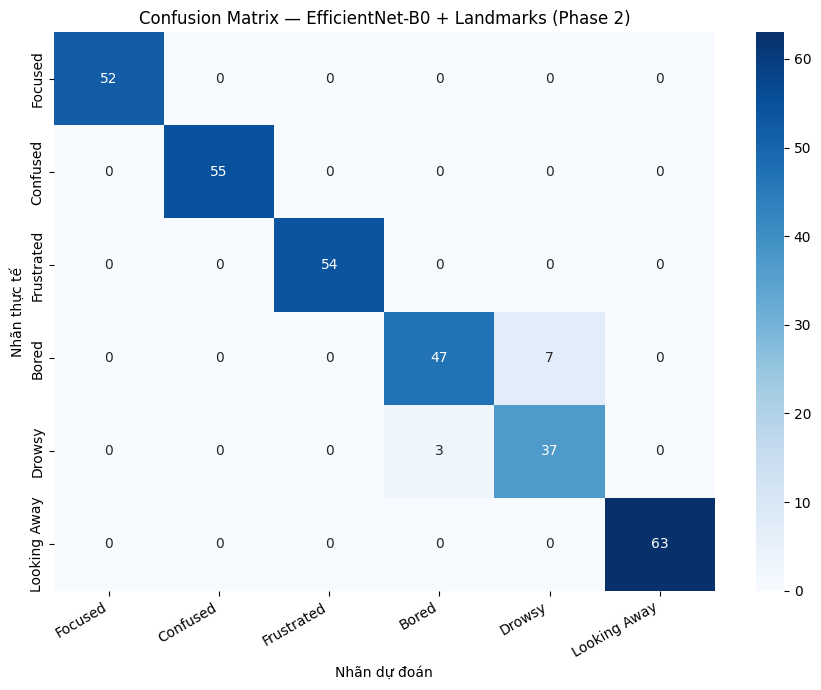

✅ Lưu confusion matrix


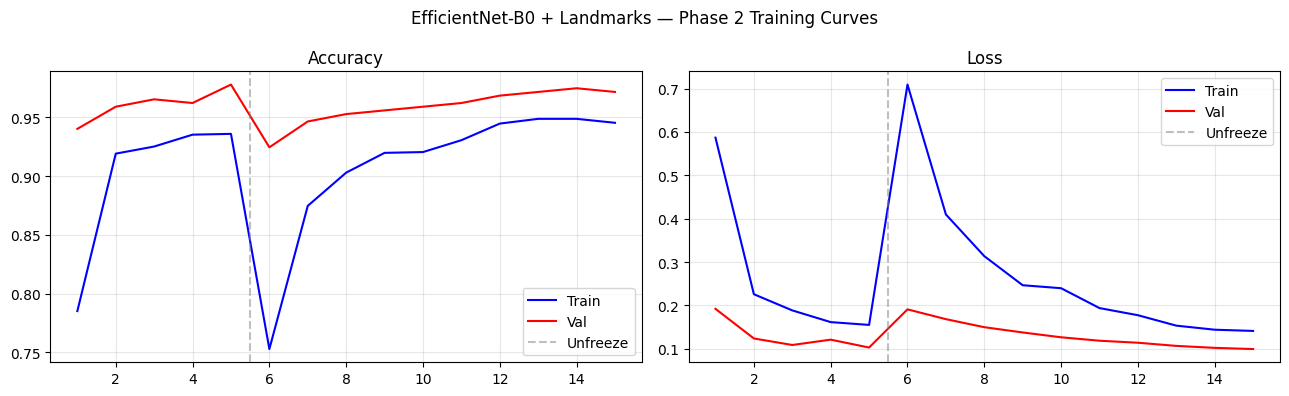

In [14]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []
for (images, lms), labels in test_student:
    preds = model_p2.predict((images, lms), verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
y_true, y_pred = np.array(y_true), np.array(y_pred)

label_names = ['Focused','Confused','Frustrated','Bored','Drowsy','Looking Away']
report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
print(classification_report(y_true, y_pred, target_names=label_names))

metrics = {
    'model': 'EfficientNetB0_Landmarks',
    'phase1_best_val_acc': float(max(history_p1_unfreeze.history['val_accuracy'])),
    'phase2_accuracy':     float(report['accuracy']),
    'macro_f1':            float(report['macro avg']['f1-score']),
    'precision':           float(report['macro avg']['precision']),
    'recall':              float(report['macro avg']['recall']),
    'per_class_f1':        {n: float(report[n]['f1-score']) for n in label_names},
    'per_class_precision': {n: float(report[n]['precision']) for n in label_names},
    'per_class_recall':    {n: float(report[n]['recall']) for n in label_names},
}
with open(f'{RESULTS_DIR}/efficientnet_lm_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"\n✅ Lưu: {RESULTS_DIR}/efficientnet_lm_metrics.json")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — EfficientNet-B0 + Landmarks (Phase 2)')
plt.ylabel('Nhãn thực tế'); plt.xlabel('Nhãn dự đoán')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/efficientnet_lm_confusion_matrix.png', dpi=150)
plt.show()
print(f'✅ Lưu confusion matrix')

# Training curves
acc_train = history_p2_freeze.history['accuracy'] + history_p2_unfreeze.history['accuracy']
acc_val   = history_p2_freeze.history['val_accuracy'] + history_p2_unfreeze.history['val_accuracy']
loss_train = history_p2_freeze.history['loss'] + history_p2_unfreeze.history['loss']
loss_val   = history_p2_freeze.history['val_loss'] + history_p2_unfreeze.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(acc_train) + 1)
axes[0].plot(epochs, acc_train, 'b-', label='Train')
axes[0].plot(epochs, acc_val, 'r-', label='Val')
axes[0].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, loss_train, 'b-', label='Train')
axes[1].plot(epochs, loss_val, 'r-', label='Val')
axes[1].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('EfficientNet-B0 + Landmarks — Phase 2 Training Curves')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/efficientnet_lm_training_curves.png', dpi=150)
plt.show()